<a href="https://www.kaggle.com/code/nadijfer/spam-email-using-ann-from-scratch?scriptVersionId=293159211" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# **Detecting Spam Email using Simple Neural Network from Scratch**

# I. Introduction

This notebook is my attempt on implementing what I've learnt in class, for have taken natural language processing (NLP) and artificial neural network (ANN). It aims to test my understanding both mathematically and in code implementation by building from scratch without any modules, except modules below. References primarily used from lecture notes and class' presentations. For this notebook, I tried to write codes and its description as clear as possible, by adding docstrings to functions.

Dataset used for this notebook is (Spam Email Dataset)[https://www.kaggle.com/datasets/jackksoncsie/spam-email-dataset] that consists of two columns: `text` for the emails feature and the label `spam` representing `1` as `spam` and `0` as ham.

The notebook will be separated into two implementation: using vanilla Bag-of-Words (BoW) for baseline and TF-IDF as its improvement.

# Baseline Implementation using BoW

In [269]:
import numpy as np
import pandas as pd
import string
import time
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import random

In [270]:
random.seed(42) # this ensures the result stays the same

# II. Exploratory Data Analysis (EDA)

In [271]:
df = pd.read_csv('/kaggle/input/spam-email-dataset/emails.csv')
df

,text,spam
0,Subject: naturally irresistible your corporate...,1
1,Subject: the stock trading gunslinger fanny i...,1
2,Subject: unbelievable new homes made easy im ...,1
3,Subject: 4 color printing special request add...,1
4,"Subject: do not have money , get software cds ...",1
...,...,...
5723,Subject: re : research and development charges...,0
5724,"Subject: re : receipts from visit jim , than...",0
5725,Subject: re : enron case study update wow ! a...,0
5726,"Subject: re : interest david , please , call...",0


### Null or NaN values

In [272]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5728 entries, 0 to 5727
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    5728 non-null   object
 1   spam    5728 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 89.6+ KB


No null or NaN value with equal distribution of both classes. We're good to go.

### Checking label distribution

<Axes: title={'center': 'Spam distribution'}, ylabel='Count'>

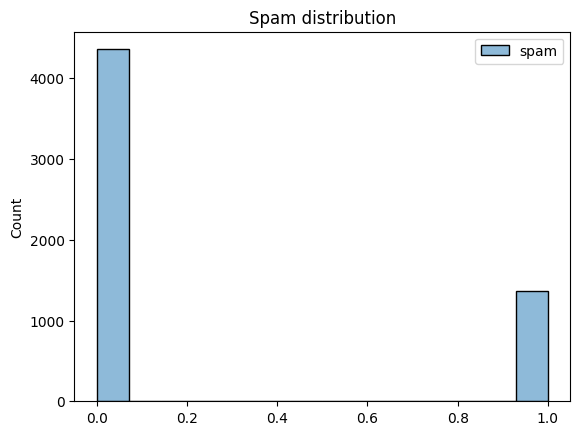

In [273]:
plt.title('Spam distribution')
sns.histplot(df)

In [274]:
len(df[df['spam'] == 0]), len(df[df['spam'] == 1])

(4360, 1368)

The distribution of the data is not well stratified, where ham (safe) emails are more frequent than the label 'spam'.

# II. Text Processing

## Cleaning and Tokenizing Documents

In [275]:
def preprotext(text):
    """Cleaning text input by applying lowercase, removing punctuation, and tokenizing (text.split()). The function could be used as:

    cleaned_texts = texts.copy()
    for i in range(len(texts)):
        cleaned_texts[i] = preprotext(texts[i])

    Args:
        text: string to be cleaned.

    Returns:
        list: tokens of cleaned text.
    """
    text = text.lower()
    text = text.translate(str.maketrans('', '', string.punctuation)) # remove punctuation marks
    tokens = text.split() # tokenizing
    return tokens

## Building Vocabulary

Vocabulary $|V|$ is a list of words model used as dictionary.

In [276]:
def build_vocab(documents):
    """Building list of words from train data for model. The function could be used as:
    vocab = build_vocab(cleaned_texts)
    len(vocab), vocab

    Args:
        documents: list of words

    Returns:
        list: vocabulary
    """
    vocab = []
    for document in documents:
        tokens = preprotext(document) # resulting tokens of each documents
        for token in tokens:
            vocab.append(token)
    
    vocab = list(set(vocab))
    vocab = {word: index for index, word in enumerate(vocab)}
    return vocab

## Encoding Text with Bag-of-Words

In [277]:
def build_bow(cleaned_texts, vocab):
    """Build BoW to a token of clened texts
    doc_bow = [] # bow for each documents
    for docs in cleaned_texts:
        docs = build_bow(docs)
        doc_bow.append(docs)
    """
    bow = np.zeros((len(vocab)))
    for token in cleaned_texts:
        if token in vocab:
            bow[vocab[token]] += 1
    return bow

# IV. Training Neural Network

The architecture of NN is built upon Multilayer Perceptron (MLP) with a hidden layer consisting 128 hidden nodes $H$. For binary target $t$, the loss function $\mathcal L$ used is binary cross entropy (BCE), defined as:

$$
\mathcal{L} = - \sum y \cdot \log (\hat y)
$$

Where $y$ is the true label (we defined in this notebook as `t` for target) and $\hat{y}$ is the prediction label (defined as `y`). 

Activation functions for input-to-hidden layer is ReLU, the function itself and its derivative defined as:

$$
\begin{align*}
f(x) & = \mathrm{ReLU} = \begin{cases}x, & \text{if } x > 0\\ 0, & \text{otherwise}\end{cases}\\
f'(x) & = \begin{cases}1\\ 0\end{cases}\\
\end{align*}
$$

and the activation functions for hidden-to-output layer is Sigmoid, both the function itself and its derivative defined as:

$$
\begin{align*}
f(x) & = \sigma = \frac{1}{1 + e^{-x}} \\
f'(x) & = f(x) (1-f(x))
\end{align*}
$$

Such architecture could be implemented as:

```
Input(len(vocab)) -> Hidden(128; Relu -> Sigmoid) -> y(1) -> L(BCE)
```

In [278]:
N = len(df) # length of all the data
H = 128 # hidden nodes (size), 1 hidden layer
lr = 1e-4 # learning rate

### Activation functions and its derivatives

In [279]:
def relu(x):
    return np.maximum(0, x)

def relu_deriv(x):
    return (x > 0).astype(float)

def sigmoid(x):
    return 1/(1+np.exp(-x))

def sigmoid_deriv(x):
    return sigmoid(x) * (1-sigmoid(x))

### Loss function and its derivative (BCE)

In [280]:
def BCE(t, y):
    return - (t * np.log(y))

def BCE_deriv(t, y): # only when sigmoid is used
    return y - t

## Train-test split

The data is splitted into train-test-validation set with proportion of 70-15-15.

In [281]:
X = df["text"]
y = df["spam"]

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.3,
    stratify=y,
    random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.5,
    stratify=y_temp,
    random_state=42
)

## Building Vocabulary, Cleaning Text and Encoding BoW

In [282]:
vocab = build_vocab(X_train)

In [283]:
len(vocab), vocab

(31909,
 {'stentofon': 0,
  'compounding': 1,
  'miliion': 2,
  'fluctuations': 3,
  'meador': 4,
  '4095': 5,
  'halich': 6,
  'austria': 7,
  'terms': 8,
  'fannie': 9,
  'blackboard': 10,
  'intergrity': 11,
  'toothbrush': 12,
  'escher': 13,
  'baker': 14,
  'trry': 15,
  'amyb': 16,
  'wsx': 17,
  'revolved': 18,
  'raghu': 19,
  'nodding': 20,
  'civilization': 21,
  'ct': 22,
  'raghunatha': 23,
  'vestry': 24,
  'adsl': 25,
  'rencontre': 26,
  'hayes': 27,
  'billed': 28,
  'ssn': 29,
  'deriv': 30,
  'armonline': 31,
  'phentrimine': 32,
  '477': 33,
  'wenz': 34,
  'metallgesellschaft': 35,
  'christos': 36,
  'ear': 37,
  'pinto': 38,
  'sharpness': 39,
  'gastronomist': 40,
  'brindle': 41,
  'hurting': 42,
  '1998': 43,
  '98111': 44,
  'mccauley': 45,
  'database': 46,
  'accessibility': 47,
  'sprit': 48,
  'iaee': 49,
  'ensembles': 50,
  'roadway': 51,
  'reciprocally': 52,
  'patrycia': 53,
  'chicago': 54,
  'miami': 55,
  'lobbying': 56,
  'synm': 57,
  'innocent'

In [284]:
train_cleaned = X_train.copy()
for i in range(len(X_train)):
    train_cleaned.iloc[i] = preprotext(train_cleaned.iloc[i])

val_cleaned = X_val.copy()
for i in range(len(X_val)):
    val_cleaned.iloc[i] = preprotext(val_cleaned.iloc[i])

In [285]:
train_cleaned

2981    [subject, jcc, forward, curve, the, following,...
22      [subject, top, level, logo, and, business, ide...
52      [subject, yyyy, do, you, know, the, hgh, diffe...
2478    [subject, carnegie, mellon, shirley, i, just, ...
4401    [subject, request, submitted, access, request,...
                              ...                        
576     [subject, new, version, 7, uncover, the, truth...
4203    [subject, re, willow, and, pathstar, evaluatio...
3549    [subject, natural, gas, production, vince, i, ...
1881    [subject, research, allocations, to, egm, hi, ...
1122    [subject, perfect, logo, charset, koi, 8, r, t...
Name: text, Length: 4009, dtype: object

In [286]:
val_cleaned

906     [subject, fast, acting, viagra, at, last, fast...
2582    [subject, eol, presentation, thank, you, for, ...
2460    [subject, re, summer, internship, shirley, fyi...
1180    [subject, call, for, papers, the, internationa...
3813    [subject, fw, mckinsey, partner, specializing,...
                              ...                        
548     [subject, save, your, money, buy, getting, thi...
4314    [subject, re, many, helyette, sorry, for, not,...
3778    [subject, interview, thanks, vince, and, stins...
3312    [subject, message, 1, dear, dr, kaminski, this...
2740    [subject, information, shalesh, please, look, ...
Name: text, Length: 859, dtype: object

In [287]:
train_bow = []
for tokens in train_cleaned:
    tokens = build_bow(tokens, vocab)
    train_bow.append(tokens)

val_bow = []
for tokens in val_cleaned:
    tokens = build_bow(tokens, vocab)
    val_bow.append(tokens)

In [288]:
train_bow

[array([0., 0., 0., ..., 0., 0., 0.]),
 array([0., 0., 0., ..., 0., 0., 0.]),
 array([0., 0., 0., ..., 0., 0., 0.]),
 array([0., 0., 0., ..., 0., 0., 0.]),
 array([0., 0., 0., ..., 0., 0., 0.]),
 array([0., 0., 0., ..., 0., 0., 0.]),
 array([0., 0., 0., ..., 0., 0., 0.]),
 array([0., 0., 0., ..., 0., 0., 0.]),
 array([0., 0., 0., ..., 0., 0., 0.]),
 array([0., 0., 0., ..., 0., 0., 0.]),
 array([0., 0., 0., ..., 0., 0., 0.]),
 array([0., 0., 0., ..., 0., 0., 0.]),
 array([0., 0., 0., ..., 0., 0., 0.]),
 array([0., 0., 0., ..., 0., 0., 0.]),
 array([0., 0., 0., ..., 0., 0., 0.]),
 array([0., 0., 0., ..., 0., 0., 0.]),
 array([0., 0., 0., ..., 0., 0., 0.]),
 array([0., 0., 0., ..., 0., 0., 0.]),
 array([0., 0., 0., ..., 0., 0., 0.]),
 array([0., 0., 0., ..., 0., 0., 0.]),
 array([0., 0., 0., ..., 0., 0., 0.]),
 array([0., 0., 0., ..., 0., 0., 0.]),
 array([0., 0., 0., ..., 0., 0., 0.]),
 array([0., 0., 0., ..., 0., 0., 0.]),
 array([0., 0., 0., ..., 0., 0., 0.]),
 array([0., 0., 0., ..., 

In [289]:
val_bow

[array([0., 0., 0., ..., 0., 0., 0.]),
 array([0., 0., 0., ..., 0., 0., 0.]),
 array([0., 0., 0., ..., 0., 0., 0.]),
 array([0., 0., 0., ..., 0., 0., 1.]),
 array([0., 0., 0., ..., 0., 0., 0.]),
 array([0., 0., 0., ..., 0., 0., 0.]),
 array([0., 0., 0., ..., 0., 0., 0.]),
 array([0., 0., 0., ..., 0., 0., 0.]),
 array([0., 0., 0., ..., 0., 0., 0.]),
 array([0., 0., 0., ..., 0., 0., 0.]),
 array([0., 0., 0., ..., 0., 0., 0.]),
 array([0., 0., 0., ..., 0., 0., 0.]),
 array([0., 0., 0., ..., 0., 0., 0.]),
 array([0., 0., 0., ..., 0., 0., 0.]),
 array([0., 0., 0., ..., 0., 0., 0.]),
 array([0., 0., 0., ..., 0., 0., 0.]),
 array([0., 0., 0., ..., 0., 0., 0.]),
 array([0., 0., 0., ..., 0., 0., 0.]),
 array([0., 0., 0., ..., 0., 0., 0.]),
 array([0., 0., 0., ..., 0., 0., 0.]),
 array([0., 0., 0., ..., 0., 0., 0.]),
 array([0., 0., 0., ..., 0., 0., 0.]),
 array([0., 0., 0., ..., 0., 0., 0.]),
 array([0., 0., 0., ..., 0., 0., 0.]),
 array([0., 0., 0., ..., 0., 0., 0.]),
 array([0., 0., 0., ..., 

## Initializing NN parameters

In [310]:
x = np.array(train_bow) # input
xv = np.array(val_bow) # validation
t = y_train.reset_index(drop=True) # target
tv = y_val.reset_index(drop=True) # target validation
w = np.random.randn(x.shape[1], H) * np.sqrt(2/len(X_train)) # He initialization
b0 = np.zeros(H) # hidden bias
v = np.random.randn(H, 1) * np.sqrt(1/H) # Xavier initialization
b1 = np.zeros(1) # output bias

In [311]:
# this cell is to check the values before and after training
params = {
    'w': w,
    'b0': b0,
    'v': v,
    'b1': b1
}

params

{'w': array([[-0.01508893,  0.03145209, -0.00610159, ..., -0.0405269 ,
          0.02130392,  0.00863193],
        [ 0.00981698,  0.00048487, -0.00704881, ..., -0.00253673,
         -0.0372689 ,  0.01237566],
        [-0.01001186,  0.01011995,  0.02140917, ..., -0.02844266,
         -0.00348386,  0.02092917],
        ...,
        [-0.00582133, -0.01037399,  0.00285272, ..., -0.03269819,
         -0.02769378, -0.00840861],
        [-0.05252187, -0.00767644, -0.03005942, ...,  0.00551569,
         -0.00590143,  0.03552572],
        [-0.03368667,  0.01796386,  0.02145976, ...,  0.01585349,
          0.00442092,  0.03040445]]),
 'b0': array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.

In [308]:
x.shape, w.shape, b0.shape, v.shape, b1.shape, xv.shape

((4009, 31909), (31909, 128), (128,), (128, 1), (1,), (859, 31909))

## Backpropagation

Backpropagation to a parameter at input layer $\theta$ could be defined as:

$$
\frac{\partial L}{\partial \theta} = \frac{\partial L}{\partial y_{out}} \frac{\partial y_{out}}{\partial y_{in}} \frac{\partial y_{in}}{\partial z_{out}} \frac{\partial z_{out}}{\partial z_{in}} \frac{\partial z_{in}}{\partial \theta}
$$

Special condition occurs to binary cross entropy (BCE) loss function when is used next to sigmoid activation function. Both BCE and its derivative could be defined as:

$$
\begin{align*}
f(x) = \mathcal{L} &= - \sum^N_{i=1} y \cdot \log(\hat{y}) \\
f'(x) &= \hat{y} - y
\end{align*}
$$

Where $y$ is the true label (we defined in this notebook as `t` for target) and $\hat{y}$ is the prediction label (defined as `y`), the function could be simplified as:

$$
\begin{align*}
\frac{\partial L}{\partial \theta} &= \frac{\partial L}{\partial y_{out}} \frac{\partial y_{out}}{\partial y_{in}} \frac{\partial y_{in}}{\partial z_{out}} \frac{\partial z_{out}}{\partial z_{in}} \frac{\partial z_{in}}{\partial \theta} \\
 & = (\hat{y}-y) \cdot v \cdot \mathrm{ReLU}'(z_{in}) \cdot \Omega
\end{align*}
$$

Where $\Omega$ depends whether observing input biases or weight biases, such as:

$$
\Omega = 
    \begin{cases}
        x, & \text{if } \theta = w,\\
        1, & \text{if } \theta = b_0
    \end{cases}
$$

Gradient to parameter $\theta$ at hidden layer could be defined as:
$$
\begin{align*}
\frac{\partial L}{\partial \theta} &= \frac{\partial L}{\partial y_{out}} \frac{\partial y_{out}}{\partial y_{in}} \frac{ \partial y_{in} }{ \partial \theta }  \\
 & = (\hat{y}-y) \cdot \Omega
\end{align*}
$$

And again, $\Omega$ depends whether observing input biases or weight biases, such as:

$$
\Omega = 
    \begin{cases}
        z, & \text{if } \theta = v,\\
        1, & \text{if } \theta = b_1
    \end{cases}
$$

In [293]:
def backpropagation(x_i, y, t_i, z_in, z_out, w, b0, v, b1, lr):
    
    delta_out = BCE_deriv(t_i, y)
    
    dv = z_out.reshape(-1, 1) * delta_out
    db1 = delta_out

    delta_hidden = (v.flatten() * delta_out) * relu_deriv(z_in)
    
    dw = np.outer(x_i, delta_hidden)
    db0 = delta_hidden
        
    v  -= lr * dv
    b1 -= lr * db1
    w  -= lr * dw
    b0 -= lr * db0

    return w, b0, v, b1

## Training

In [314]:
train_loss = []
val_loss = []
max_epochs = 10

start = time.time()
for epoch in range(max_epochs):

    # training
    total_train_loss = 0
    for i in range(len(x)):
        z_in = x[i] @ w + b0
        z_out = relu(z_in)
        y_in = z_out @ v + b1
        y = sigmoid(y_in)

        loss = BCE(t[i], y)
        total_train_loss += loss

        w, b0, v, b1 = backpropagation(x[i], y, t[i], z_in, z_out, w, b0, v, b1, lr)

    avg_train_loss = total_train_loss/len(x)
    train_loss.append(avg_train_loss)

    # validation
    total_val_loss = 0
    for i in range(len(xv)):
        z_in = xv[i] @ w + b0
        z_out = relu(z_in)
        y_in = z_out @ v + b1
        y = sigmoid(y_in)

        loss = BCE(tv[i], y)
        total_val_loss += loss

    avg_val_loss = total_val_loss / len(xv)
    val_loss.append(avg_val_loss)
    
    print(f'epoch {epoch+1} | train: {avg_train_loss} | val: {avg_val_loss}')
    
end = (time.time() - start) / 60
print(f'\ntraining time: {end:.2f} minutes')

epoch 1 | train: [0.23457969] | val: [0.20093944]
epoch 2 | train: [0.18503459] | val: [0.16499124]
epoch 3 | train: [0.16255864] | val: [0.14487716]
epoch 4 | train: [0.14486858] | val: [0.1302102]
epoch 5 | train: [0.13091279] | val: [0.11931638]
epoch 6 | train: [0.11985919] | val: [0.11091106]
epoch 7 | train: [0.1108129] | val: [0.10403553]
epoch 8 | train: [0.10309578] | val: [0.09821719]
epoch 9 | train: [0.09645007] | val: [0.09314952]
epoch 10 | train: [0.09057267] | val: [0.08860035]

training time: 26.37 minutes


In [315]:
params

{'w': array([[-0.01508893,  0.03140925, -0.00626728, ..., -0.0405269 ,
          0.02128923,  0.00856804],
        [ 0.00981698,  0.00052859, -0.00688213, ..., -0.00258007,
         -0.03725352,  0.01245119],
        [-0.00998242,  0.01025462,  0.02210773, ..., -0.02856553,
         -0.00346767,  0.02125823],
        ...,
        [-0.00583367, -0.01037999,  0.00278988, ..., -0.03269202,
         -0.0276946 , -0.00842463],
        [-0.05252187, -0.00765031, -0.02995886, ...,  0.00551569,
         -0.00589323,  0.03557222],
        [-0.03365132,  0.01828418,  0.02309117, ...,  0.01565968,
          0.00444067,  0.03110974]]),
 'b0': array([-6.37739831e-04,  1.36459291e-03, -8.29533842e-04, -3.21622978e-03,
        -1.17040055e-03, -4.16441062e-04,  1.05176444e-02, -9.95341895e-04,
         4.59262579e-04,  5.25098607e-03,  4.83168304e-03, -3.40676108e-04,
         1.72805586e-02,  3.29329950e-03,  2.45844929e-03,  4.23408758e-03,
        -1.27703848e-03,  2.02232622e-02,  2.98976972e-04,

# V. Inference

## Cleaning Text and Encoding BoW for Data Test

In [316]:
test_cleaned = X_test.copy()
for i in range(len(X_test)):
    test_cleaned.iloc[i] = preprotext(test_cleaned.iloc[i])

In [317]:
test_bow = []
for tokens in test_cleaned:
    tokens = build_bow(tokens, vocab)
    test_bow.append(tokens)

## Prediction

In [318]:
xt = np.array(test_bow)
y_preds = []
    
for i in range(len(xt)):
    z_in = xt[i] @ w + b0
    z_out = relu(z_in)
    y_in = z_out @ v + b1
    y = sigmoid(y_in)
    y_preds.append(y)

y_preds = np.array(y_preds)
y_hat = (y_preds >= 0.5).astype(int)

In [319]:
accuracy = accuracy_score(y_test, y_hat) * 100
precision = precision_score(y_test, y_hat) * 100
recall = recall_score(y_test, y_hat) * 100
f1 = f1_score(y_test, y_hat) * 100

print(f'accuracy: {accuracy:.2f}\nprecision: {precision:.2f}\nrecall: {recall:.2f}\nf1-score: {f1:.2f}')

accuracy: 93.60
precision: 94.15
recall: 78.16
f1-score: 85.41


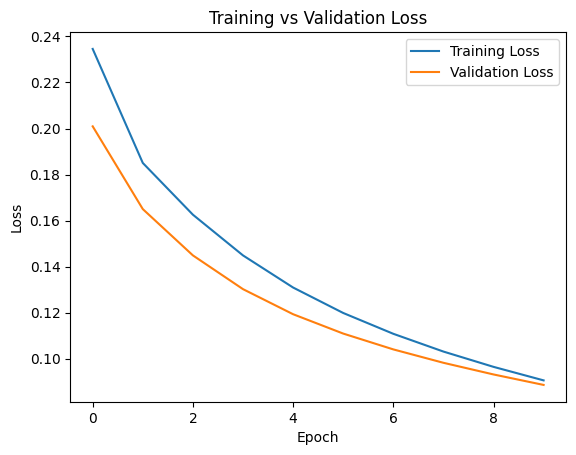

In [323]:
plt.plot(train_loss, label="Training Loss")
plt.plot(val_loss, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("Training vs Validation Loss")
plt.show()

# VI. Discussion

From the above scores, model scored high for accuracy and precision, yet recall is lower with only 78% recall. This can be concluded that the model's performance for detecting FN is weaker than the other metrics, so that model could not identify spam label; mistakenly put spam label as ham. This happens because vanilla BoW is not designed to "pay attention" to context. Each words are independent on its own.

Even though the accuracy is high, the model could not be concluded as completely overfitting. This is because the plot of both training loss and validation loss is gradually going smaller. 

To counter the context problem, TF-IDF is a solution for reducing the context problem by calculating weight for each words.

# Improvement with vanilla TF-IDF

In [326]:
def calcTermFrequency(documents):
    termFreqList = []
    for document in documents:
        tf_doc = {} # term frequency for every documents
        for token in document:
            tf_doc[token] = tf_doc.get(token, 0) + 1
        termFreqList.append(tf_doc)
    return termFreqList

def calcDocFrequency(termFreqList):
    df = {}
    for tf_doc in termFreqList:
        for token in tf_doc.keys():
            df[token] = df.get(token, 0) + 1
    return df

def calcIDF(N, docFreq):
    idfList = {}
    for df in docFreq:
        idf_df = np.log10(N/docFreq.get(df))
        idfList.update({df: idf_df})
    return idfList

def calcTFIDF(termFreq, docFreq, idf):
    tf_idf = [] 
    for tf in termFreq:
        tf_idf_doc = {}
        for tokens in tf:
            tf_idf_doc[tokens] = tf[tokens] * idf[tokens]
        tf_idf.append(tf_idf_doc)
    return tf_idf

In [332]:
# train
tf_train = calcTermFrequency(train_cleaned)
df_train = calcDocFrequency(tf_train)
idf_train = calcIDF(train_cleaned.shape[0], df_train)
tf_idf_train = calcTFIDF(tf_train, df_train, idf_train)

# validation
tf_val = calcTermFrequency(val_cleaned)
df_val = calcDocFrequency(tf_val)
idf_val = calcIDF(val_cleaned.shape[0], df_val)
tf_idf_val = calcTFIDF(tf_val, df_val, idf_val)

## Training with TF-IDF

In [328]:
word2idx = {word: i for i, word in enumerate(vocab)}
word2idx

{'stentofon': 0,
 'compounding': 1,
 'miliion': 2,
 'fluctuations': 3,
 'meador': 4,
 '4095': 5,
 'halich': 6,
 'austria': 7,
 'terms': 8,
 'fannie': 9,
 'blackboard': 10,
 'intergrity': 11,
 'toothbrush': 12,
 'escher': 13,
 'baker': 14,
 'trry': 15,
 'amyb': 16,
 'wsx': 17,
 'revolved': 18,
 'raghu': 19,
 'nodding': 20,
 'civilization': 21,
 'ct': 22,
 'raghunatha': 23,
 'vestry': 24,
 'adsl': 25,
 'rencontre': 26,
 'hayes': 27,
 'billed': 28,
 'ssn': 29,
 'deriv': 30,
 'armonline': 31,
 'phentrimine': 32,
 '477': 33,
 'wenz': 34,
 'metallgesellschaft': 35,
 'christos': 36,
 'ear': 37,
 'pinto': 38,
 'sharpness': 39,
 'gastronomist': 40,
 'brindle': 41,
 'hurting': 42,
 '1998': 43,
 '98111': 44,
 'mccauley': 45,
 'database': 46,
 'accessibility': 47,
 'sprit': 48,
 'iaee': 49,
 'ensembles': 50,
 'roadway': 51,
 'reciprocally': 52,
 'patrycia': 53,
 'chicago': 54,
 'miami': 55,
 'lobbying': 56,
 'synm': 57,
 'innocent': 58,
 'criterion': 59,
 'pessimistic': 60,
 'won': 61,
 'virtual':

In [329]:
def tfidf_to_vector(tfidf_doc, vocab):
    vec = np.zeros(len(vocab))
    for token, value in tfidf_doc.items():
        if token in vocab:
            vec[vocab[token]] = value
    return vec

In [334]:
x = np.array([
    tfidf_to_vector(doc, word2idx)
    for doc in tf_idf_train
])

xv = np.array([
    tfidf_to_vector(doc, word2idx)
    for doc in tf_idf_val
])

In [337]:
t = y_train.reset_index(drop=True) # target
tv = y_val.reset_index(drop=True) # target validation
w = np.random.randn(x.shape[1], H) * np.sqrt(2/x.shape[0]) # He initialization
b0 = np.zeros(H) # hidden bias
v = np.random.randn(H, 1) * np.sqrt(1/H) # Xavier initialization
b1 = np.zeros(1) # output bias

In [338]:
w, b0, v, b1

(array([[ 0.00730704,  0.01113861, -0.00449706, ..., -0.01704188,
          0.00391862,  0.03577939],
        [ 0.02424365, -0.03344245, -0.02037408, ..., -0.01290301,
          0.02704933,  0.01410426],
        [ 0.00478243,  0.02816314,  0.01301993, ...,  0.02136513,
         -0.00682105,  0.00174241],
        ...,
        [-0.00696277,  0.01508064,  0.0018039 , ..., -0.01909973,
          0.02811861,  0.00478261],
        [-0.01520487, -0.04330794,  0.00485885, ..., -0.04230629,
         -0.01761993,  0.01655112],
        [ 0.02277201,  0.02417302,  0.01809022, ...,  0.04014368,
         -0.01423067,  0.01106303]]),
 array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0

In [339]:
train_loss = []
val_loss = []
max_epochs = 10

start = time.time()
for epoch in range(max_epochs):

    # training
    total_train_loss = 0
    for i in range(len(x)):
        z_in = x[i] @ w + b0
        z_out = relu(z_in)
        y_in = z_out @ v + b1
        y = sigmoid(y_in)

        loss = BCE(t[i], y)
        total_train_loss += loss

        w, b0, v, b1 = backpropagation(x[i], y, t[i], z_in, z_out, w, b0, v, b1, lr)

    avg_train_loss = total_train_loss/len(x)
    train_loss.append(avg_train_loss)

    # validation
    total_val_loss = 0
    for i in range(len(xv)):
        z_in = xv[i] @ w + b0
        z_out = relu(z_in)
        y_in = z_out @ v + b1
        y = sigmoid(y_in)

        loss = BCE(tv[i], y)
        total_val_loss += loss

    avg_val_loss = total_val_loss / len(xv)
    val_loss.append(avg_val_loss)
    
    print(f'epoch {epoch+1} | train: {avg_train_loss} | val: {avg_val_loss}')
    
end = (time.time() - start) / 60
print(f'\ntraining time: {end:.2f} minutes')

epoch 1 | train: [0.19600744] | val: [0.20851871]
epoch 2 | train: [0.20461314] | val: [0.19537769]
epoch 3 | train: [0.18773994] | val: [0.18228121]
epoch 4 | train: [0.17256511] | val: [0.16974647]
epoch 5 | train: [0.15871139] | val: [0.15898045]
epoch 6 | train: [0.14667413] | val: [0.14879553]
epoch 7 | train: [0.13556131] | val: [0.13940119]
epoch 8 | train: [0.12545836] | val: [0.13081165]
epoch 9 | train: [0.11634191] | val: [0.12310948]
epoch 10 | train: [0.10811244] | val: [0.11615141]

training time: 17.92 minutes


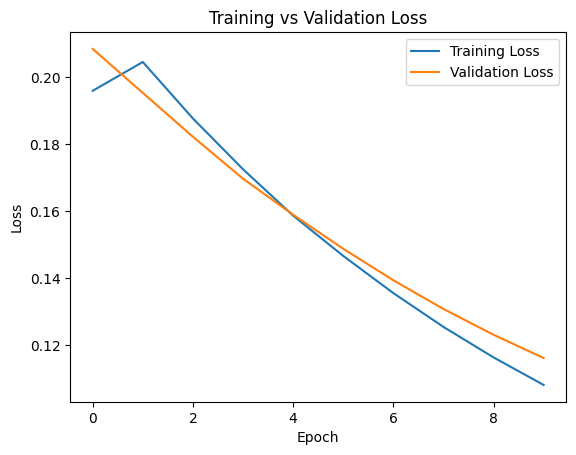

In [345]:
plt.plot(train_loss, label="Training Loss")
plt.plot(val_loss, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("Training vs Validation Loss")
plt.show()

In [340]:
w, b0, v, b1

(array([[ 0.00699522,  0.01110781, -0.00449706, ..., -0.01704188,
          0.00430695,  0.03574272],
        [ 0.02420089, -0.03343073, -0.02031684, ..., -0.01276836,
          0.02710314,  0.01411967],
        [ 0.00596482,  0.0282806 ,  0.0131831 , ...,  0.0226592 ,
         -0.00704283,  0.00179121],
        ...,
        [-0.00707156,  0.01507172,  0.00169675, ..., -0.01927713,
          0.02837758,  0.00473708],
        [-0.01520487, -0.04330794,  0.00485885, ..., -0.04230629,
         -0.01761993,  0.01655112],
        [ 0.02441171,  0.02436124,  0.01874842, ...,  0.04140196,
         -0.01514283,  0.01122578]]),
 array([-0.00259967, -0.00062804, -0.00254261,  0.0023663 , -0.00927794,
        -0.00165117,  0.00448785,  0.0016137 ,  0.03821231, -0.00425932,
         0.02117672,  0.00319827,  0.00112531, -0.0038881 ,  0.01072479,
        -0.00096444,  0.02336774,  0.00282857, -0.00038203, -0.00435573,
         0.01044024, -0.00342162, -0.00764462, -0.00543397,  0.01000601,
        

## Testing

In [341]:
tf_test = calcTermFrequency(test_cleaned)
df_test = calcDocFrequency(tf_test)
idf_test = calcIDF(test_cleaned.shape[0], df_test)
tf_idf_test = calcTFIDF(tf_test, df_test, idf_test)

In [342]:
xt = np.array([
    tfidf_to_vector(doc, word2idx)
    for doc in tf_idf_test
])

In [357]:
y_preds = []
    
for i in range(len(xt)):
    z_in = xt[i] @ w + b0
    z_out = relu(z_in)
    y_in = z_out @ v + b1
    y = sigmoid(y_in)
    y_preds.append(y)

y_preds = np.array(y_preds)

A TF-IDF model should result lower probability values than BoW because of IDF logarithmic factor, which defined as:

$$
IDF(t) = \log \left(\frac{N}{DF(t)}\right)
$$

This creates small input values $X$ that is fed to NN, resulting the dot product $x^{\intercal}w$ is closer to 0, which affect `y` lies in almost linear area between 0.4 to 0.6. For example, for both 0.00085 and -0.00085, its sigmoid result would be:

$$
\begin{align*}
\sigma(0.00085) &= \frac{1}{1 + \exp(-0.0085)} = 0.500212 \\
\sigma(-0.00085) &= \frac{1}{1 + \exp(0.0085)} = 0.499788
\end{align*}
$$

If the threshold is not changed for a _different_, more sensitive case for TF-IDF, overall metrics would be bad. Below is the example with unchanged threshold.

In [363]:
y_hat = (y_preds >= 0.5).astype(int)

accuracy = accuracy_score(y_test, y_hat) * 100
precision = precision_score(y_test, y_hat) * 100
recall = recall_score(y_test, y_hat) * 100
f1 = f1_score(y_test, y_hat) * 100

print(f'accuracy: {accuracy:.2f}\nprecision: {precision:.2f}\nrecall: {recall:.2f}\nf1-score: {f1:.2f}')

accuracy: 91.51
precision: 97.16
recall: 66.50
f1-score: 78.96


And for modified threshold:

In [364]:
y_hat = (y_preds >= 0.4).astype(int)

accuracy = accuracy_score(y_test, y_hat) * 100
precision = precision_score(y_test, y_hat) * 100
recall = recall_score(y_test, y_hat) * 100
f1 = f1_score(y_test, y_hat) * 100

print(f'accuracy: {accuracy:.2f}\nprecision: {precision:.2f}\nrecall: {recall:.2f}\nf1-score: {f1:.2f}')

accuracy: 95.81
precision: 90.09
recall: 92.72
f1-score: 91.39


From the result above, a vanilla TF-IDF model performs well on this spam/ham email classification with threshold 0.4. All four metrics exceeded 90%. This can be concluded that TF-IDF improvement is succeed.